# Sampling Distributions of Histogram Bin Counts
## *What happens to a single bin when you repeat the same experiment 10,000 times?*

When you fill a histogram, each bin gets some count. Run the same experiment again — the counts change. Run it 10,000 times and you can ask: **what is the distribution of those counts?**

This is the sampling distribution of a bin count — the distribution of a statistic computed from repeated random samples.

We generate N_evt = 100 uniform random numbers and bin them into 5 equal bins. Each bin expects 20 entries on average (100 × 1/5). We repeat this N_exp = 10,000 times and study:
- What distribution do the counts follow? Binomial, Poisson, or Normal?
- Are counts in different bins correlated with each other?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

N_evt  = 100     # uniform random numbers per experiment
N_exp  = 10_000  # number of repeated experiments
N_bins = 5       # histogram bins

p_bin  = 1.0 / N_bins   # probability of landing in any single bin
expected_count = N_evt * p_bin

print(f"Events per experiment  : {N_evt}")
print(f"Number of experiments  : {N_exp:,}")
print(f"Number of bins         : {N_bins}")
print(f"P(landing in one bin)  : {p_bin}")
print(f"Expected count per bin : {expected_count}")

Events per experiment  : 100
Number of experiments  : 10,000
Number of bins         : 5
P(landing in one bin)  : 0.2
Expected count per bin : 20.0


---
## Run the Experiment N_exp Times

Each experiment: draw 100 uniform numbers in [0, 1], bin them into 5 equal bins.
Record the count in each bin. Repeat 10,000 times.

In [2]:
# bin_counts[i, j] = count in bin j for experiment i
# Shape: (N_exp, N_bins)
bin_counts = np.zeros((N_exp, N_bins), dtype=int)

for i in range(N_exp):
    samples = np.random.uniform(0, 1, N_evt)
    counts, _ = np.histogram(samples, bins=N_bins, range=(0, 1))
    bin_counts[i] = counts

print(f"bin_counts shape: {bin_counts.shape}  (experiments × bins)")
print(f"\nFirst 5 experiments (each row sums to {N_evt}):")
print(bin_counts[:5])
print(f"\nRow sums (should all be {N_evt}): {bin_counts[:5].sum(axis=1)}")
print(f"\nMean count per bin across all experiments:")
print(np.round(bin_counts.mean(axis=0), 2))

bin_counts shape: (10000, 5)  (experiments × bins)

First 5 experiments (each row sums to 100):
[[28 18 17 19 18]
 [18 26 15 17 24]
 [20 19 16 24 21]
 [24 15 19 24 18]
 [24 15 19 17 25]]

Row sums (should all be 100): [100 100 100 100 100]

Mean count per bin across all experiments:
[19.94 20.02 19.99 20.03 20.03]


---
## Part (a) — Distribution of a Single Bin

We pick bin 1 (zero-indexed) and plot the distribution of its counts
across all 10,000 experiments.

Bin 1 count statistics across 10,000 experiments:
  Mean     : 20.0241  (expected: 20.0)
  Variance : 16.3437
  Std dev  : 4.0427
  Min/Max  : 8 / 36


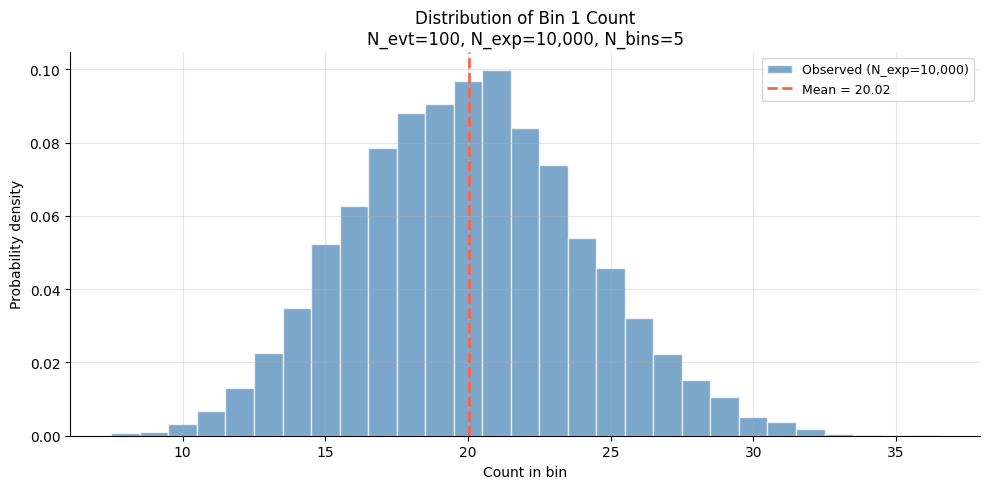

In [3]:
chosen_bin = 1  # zero-indexed, so this is the second bin [0.2, 0.4)
counts_bin = bin_counts[:, chosen_bin]

print(f"Bin {chosen_bin} count statistics across {N_exp:,} experiments:")
print(f"  Mean     : {counts_bin.mean():.4f}  (expected: {expected_count})")
print(f"  Variance : {counts_bin.var():.4f}")
print(f"  Std dev  : {counts_bin.std():.4f}")
print(f"  Min/Max  : {counts_bin.min()} / {counts_bin.max()}")

fig, ax = plt.subplots(figsize=(10, 5))

bins_range = np.arange(counts_bin.min(), counts_bin.max() + 2)
ax.hist(counts_bin, bins=bins_range - 0.5, density=True,
        color='steelblue', alpha=0.7, edgecolor='white',
        label=f'Observed (N_exp={N_exp:,})')

ax.axvline(counts_bin.mean(), color='tomato', lw=2, linestyle='--',
           label=f'Mean = {counts_bin.mean():.2f}')

ax.set_xlabel('Count in bin')
ax.set_ylabel('Probability density')
ax.set_title(f'Distribution of Bin {chosen_bin} Count\nN_evt={N_evt}, N_exp={N_exp:,}, N_bins={N_bins}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bin_count_distribution.png', dpi=150)
plt.show()

---
## Part (b) — Which PDF Describes This Distribution?

The count in a single bin is a classic **Binomial** process:
- n = 100 trials (the uniform numbers drawn)
- p = 1/5 = 0.20 probability of landing in our bin
- Trials are independent

So the exact distribution is **Binomial(n=100, p=0.2)**.

Two approximations are commonly applied:
- **Poisson(λ=20)** — valid when n is large and p is small. Here p=0.2 is not particularly small, so this is an approximation.
- **Normal(μ=20, σ²=16)** — valid by the Central Limit Theorem for large n. Continuous, so it smooths over the discrete nature of counts.

Key distinction: Binomial variance = np(1-p) = **16**. Poisson variance = λ = **20**. Normal uses the binomial variance. We can test which fits the data better.

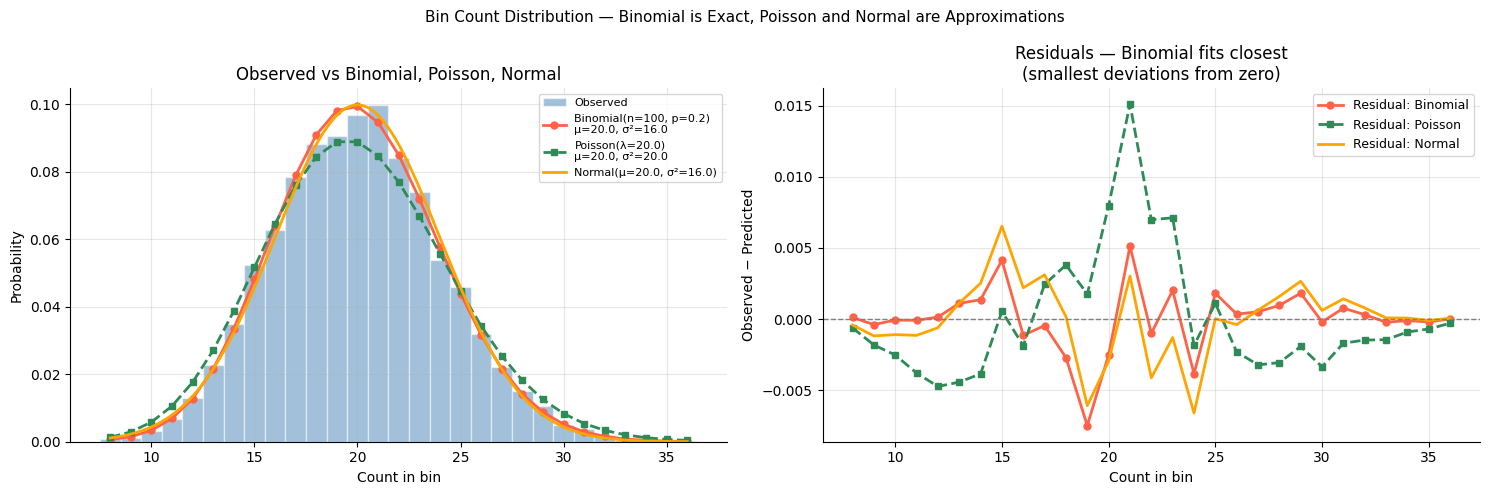

Theoretical predictions:
  Binomial : mean = 20.00,  variance = 16.00
  Poisson  : mean = 20.00,  variance = 20.00
  Normal   : mean = 20.00,  variance = 16.00

Observed from simulation:
  Mean     = 20.0241
  Variance = 16.3437

The observed variance (16.34) matches Binomial (16.0) more closely
than Poisson (20.00), confirming Binomial is the correct description.


In [4]:
mu       = N_evt * p_bin          # = 20
var_binom = N_evt * p_bin * (1 - p_bin)  # = 16
sigma    = np.sqrt(var_binom)     # = 4

x_discrete = np.arange(counts_bin.min(), counts_bin.max() + 1)
x_cont     = np.linspace(counts_bin.min(), counts_bin.max(), 300)

pmf_binomial = stats.binom.pmf(x_discrete, n=N_evt, p=p_bin)
pmf_poisson  = stats.poisson.pmf(x_discrete, mu=mu)
pdf_normal   = stats.norm.pdf(x_cont, loc=mu, scale=sigma)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: all three overlaid on histogram
axes[0].hist(counts_bin, bins=bins_range - 0.5, density=True,
             color='steelblue', alpha=0.5, edgecolor='white', label='Observed')
axes[0].plot(x_discrete, pmf_binomial, 'o-', color='tomato',    lw=2, ms=5,
             label=f'Binomial(n={N_evt}, p={p_bin})\nμ={mu}, σ²={var_binom}')
axes[0].plot(x_discrete, pmf_poisson,  's--', color='seagreen', lw=2, ms=5,
             label=f'Poisson(λ={mu})\nμ={mu}, σ²={mu}')
axes[0].plot(x_cont, pdf_normal, '-',  color='orange',          lw=2,
             label=f'Normal(μ={mu}, σ²={var_binom})')
axes[0].set_xlabel('Count in bin')
axes[0].set_ylabel('Probability')
axes[0].set_title('Observed vs Binomial, Poisson, Normal')
axes[0].legend(fontsize=8)

# Panel 2: residuals — how far is each fit from the observed?
obs_freq, _ = np.histogram(counts_bin, bins=bins_range - 0.5, density=True)
x_obs = x_discrete[:len(obs_freq)]
pmf_b = stats.binom.pmf(x_obs, n=N_evt, p=p_bin)
pmf_p = stats.poisson.pmf(x_obs, mu=mu)
pdf_n = stats.norm.pdf(x_obs, loc=mu, scale=sigma)

axes[1].plot(x_obs, obs_freq - pmf_b, 'o-', color='tomato',   lw=2, ms=5, label='Residual: Binomial')
axes[1].plot(x_obs, obs_freq - pmf_p, 's--', color='seagreen', lw=2, ms=5, label='Residual: Poisson')
axes[1].plot(x_obs, obs_freq - pdf_n, '-',  color='orange',    lw=2,       label='Residual: Normal')
axes[1].axhline(0, color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('Count in bin')
axes[1].set_ylabel('Observed − Predicted')
axes[1].set_title('Residuals — Binomial fits closest\n(smallest deviations from zero)')
axes[1].legend(fontsize=9)

plt.suptitle('Bin Count Distribution — Binomial is Exact, Poisson and Normal are Approximations', fontsize=11)
plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)
plt.show()

print(f"Theoretical predictions:")
print(f"  Binomial : mean = {mu:.2f},  variance = {var_binom:.2f}")
print(f"  Poisson  : mean = {mu:.2f},  variance = {float(mu):.2f}")
print(f"  Normal   : mean = {mu:.2f},  variance = {var_binom:.2f}")
print(f"\nObserved from simulation:")
print(f"  Mean     = {counts_bin.mean():.4f}")
print(f"  Variance = {counts_bin.var():.4f}")
print(f"\nThe observed variance ({counts_bin.var():.2f}) matches Binomial ({var_binom}) more closely")
print(f"than Poisson ({float(mu):.2f}), confirming Binomial is the correct description.")

---
## Part (c) — Are Bin Counts Correlated?

We scatter plot the counts of bin 2 vs bin 4 across all 10,000 experiments.

**What should we expect?**

The total count per experiment is always fixed at N_evt = 100. If bin 2 gets an unusually high count in one experiment, the remaining bins collectively must get fewer — there are only 100 numbers to go around. So bins must be **negatively correlated**.

This is a consequence of the multinomial constraint: the bin counts are not independent. They sum to a constant, which forces a negative correlation between any pair of bins.

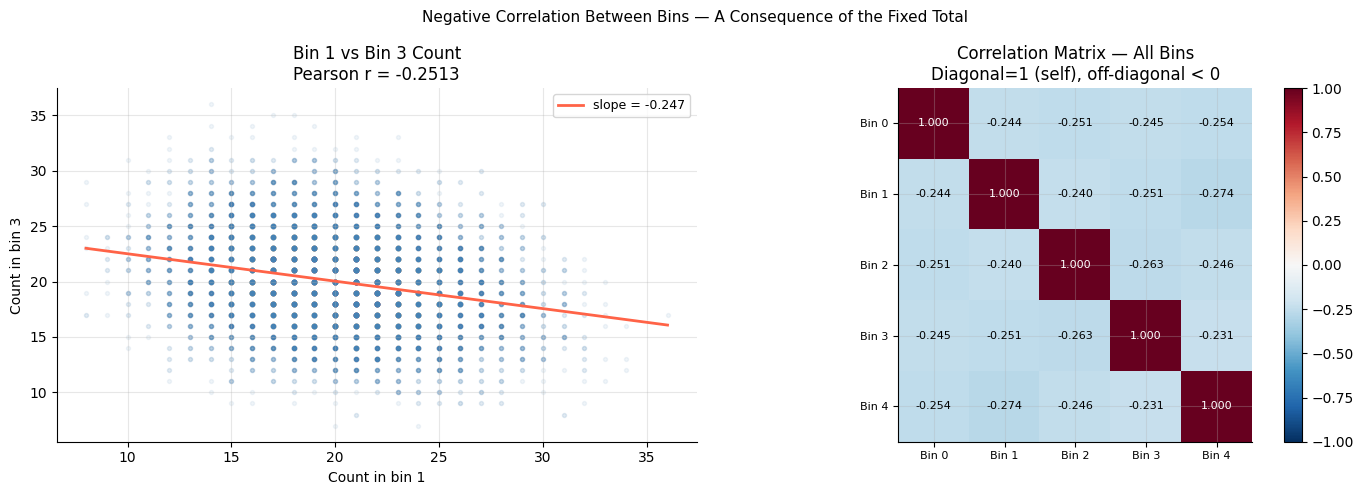

Observed correlation between bin 1 and bin 3: -0.251277
Theoretical (multinomial):                               -0.250000

All off-diagonal correlations (should all be ≈ -0.2500):
  Bin 0 vs Bin 1: -0.2445
  Bin 0 vs Bin 2: -0.2508
  Bin 0 vs Bin 3: -0.2454
  Bin 0 vs Bin 4: -0.2536
  Bin 1 vs Bin 2: -0.2400
  Bin 1 vs Bin 3: -0.2513
  Bin 1 vs Bin 4: -0.2742
  Bin 2 vs Bin 3: -0.2628
  Bin 2 vs Bin 4: -0.2462
  Bin 3 vs Bin 4: -0.2313


In [5]:
bin_a = 1  # bin 2 (zero-indexed)
bin_b = 3  # bin 4 (zero-indexed)

counts_a = bin_counts[:, bin_a]
counts_b = bin_counts[:, bin_b]

correlation = np.corrcoef(counts_a, counts_b)[0, 1]

# Theoretical correlation for multinomial: -p / (1-p) ... for equal bins: -1/(N_bins-1)
theoretical_corr = -p_bin / (1 - p_bin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with density colouring
axes[0].scatter(counts_a, counts_b, alpha=0.08, s=8, color='steelblue')
axes[0].set_xlabel(f'Count in bin {bin_a}')
axes[0].set_ylabel(f'Count in bin {bin_b}')
axes[0].set_title(f'Bin {bin_a} vs Bin {bin_b} Count\nPearson r = {correlation:.4f}')

# Add regression line
m, b = np.polyfit(counts_a, counts_b, 1)
x_line = np.linspace(counts_a.min(), counts_a.max(), 100)
axes[0].plot(x_line, m * x_line + b, color='tomato', lw=2,
             label=f'slope = {m:.3f}')
axes[0].legend(fontsize=9)

# Correlation matrix for all 5 bins
corr_matrix = np.corrcoef(bin_counts.T)
im = axes[1].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(N_bins))
axes[1].set_yticks(range(N_bins))
axes[1].set_xticklabels([f'Bin {i}' for i in range(N_bins)], fontsize=8)
axes[1].set_yticklabels([f'Bin {i}' for i in range(N_bins)], fontsize=8)
axes[1].set_title('Correlation Matrix — All Bins\nDiagonal=1 (self), off-diagonal < 0')
for i in range(N_bins):
    for j in range(N_bins):
        axes[1].text(j, i, f'{corr_matrix[i,j]:.3f}',
                     ha='center', va='center', fontsize=8,
                     color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')

plt.suptitle('Negative Correlation Between Bins — A Consequence of the Fixed Total', fontsize=11)
plt.tight_layout()
plt.savefig('bin_correlation.png', dpi=150)
plt.show()

print(f"Observed correlation between bin {bin_a} and bin {bin_b}: {correlation:.6f}")
print(f"Theoretical (multinomial):                               {theoretical_corr:.6f}")
print(f"\nAll off-diagonal correlations (should all be ≈ {theoretical_corr:.4f}):")
for i in range(N_bins):
    for j in range(i+1, N_bins):
        print(f"  Bin {i} vs Bin {j}: {corr_matrix[i,j]:.4f}")

---
## Summary

**Part a** — The distribution of a single bin count across 10,000 experiments is bell-shaped and centred at the expected value of 20.

**Part b** — The exact distribution is **Binomial(n=100, p=0.2)**. Poisson and Normal are approximations:
- Poisson overestimates the variance (λ=20 vs true variance=16) because p=0.2 is not small enough for the Poisson approximation to be tight
- Normal fits well visually but is continuous — it assigns probability to non-integer and negative counts
- The observed variance from simulation confirms the Binomial prediction

**Part c** — Bin counts are **negatively correlated**. The theoretical Pearson correlation for equal-width bins is −p/(1−p) = −1/(N_bins−1) ≈ −0.25. This is a direct consequence of the multinomial constraint: the bin counts must sum to N_evt = 100 in every experiment, so a high count in one bin forces lower counts elsewhere.

**Connection to data analysis practice:**

This negative correlation is often ignored in histogram analyses — bins are treated as independent measurements. For most applications this is a reasonable approximation, but in precision measurements (particle physics, clinical trials) it matters. The covariance structure of histogram bins must be accounted for when fitting models to histogrammed data.